In [ ]:
import os, math, random, shutil
import numpy as np
import tensorflow as tf
import keras
from keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

DATA_DIR = "/home/lurpd/DevelopmentWSL2/Datasets/BWSET/train"
IMG_SIZE = 256
BATCH = 64
SEED = 42 


TF: 2.21.0-dev20251017
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [68]:
#undersample

# --- Paths ---
original_dir = "/home/lurpd/DevelopmentWSL2/Datasets/BWSET/train"
balanced_dir = "/home/lurpd/DevelopmentWSL2/Datasets/BWSET/balanced"

# --- Clean previous balanced directory (if exists) ---
if os.path.exists(balanced_dir):
    shutil.rmtree(balanced_dir)
os.makedirs(balanced_dir, exist_ok=True)

# --- Count images in each class ---
class_counts = {}
for cls in os.listdir(original_dir):
    cls_path = os.path.join(original_dir, cls)
    if os.path.isdir(cls_path):
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('.')]
        class_counts[cls] = len(images)

print("Class counts:", class_counts)

# --- Find the smallest class size ---
target = min(class_counts.values())
print(f"\nUndersampling all classes to {target} images each\n")

# --- Undersample each class ---
for cls, count in class_counts.items():
    src_folder = os.path.join(original_dir, cls)
    dst_folder = os.path.join(balanced_dir, cls)
    os.makedirs(dst_folder, exist_ok=True)

    # Get random subset of images equal to smallest class size
    files = [f for f in os.listdir(src_folder)
             if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('.')]
    sampled_files = random.sample(files, target)

    # Create symlinks (lightweight, doesn’t duplicate files)
    for f in sampled_files:
        src = os.path.join(src_folder, f)
        dst = os.path.join(dst_folder, f)
        os.symlink(src, dst)

# --- Verify counts ---
for cls in os.listdir(balanced_dir):
    c = len(os.listdir(os.path.join(balanced_dir, cls)))
    print(f"{cls}: {c} images")


Class counts: {'c2': 1525, 'c1': 2512, 'c0': 6180}

Undersampling all classes to 1525 images each

c2: 1525 images
c1: 1525 images
c0: 1525 images


In [69]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    fill_mode='nearest'
)
val_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_gen.flow_from_directory(
    original_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)
val_generator = val_gen.flow_from_directory(
    original_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print("Classes:", train_generator.class_indices)


Found 8174 images belonging to 3 classes.
Found 2043 images belonging to 3 classes.
Classes: {'c0': 0, 'c1': 1, 'c2': 2}


In [70]:
#debug count data
import collections

class_counts = collections.Counter(train_generator.classes)
for cls, count in class_counts.items():
    print(f"{cls} ({list(train_generator.class_indices.keys())[cls]}): {count}")

0 (c0): 4944
1 (c1): 2010
2 (c2): 1220


(64, 256, 256, 1)
(64, 3)
(64, 256, 256, 1) 0.0 1.0


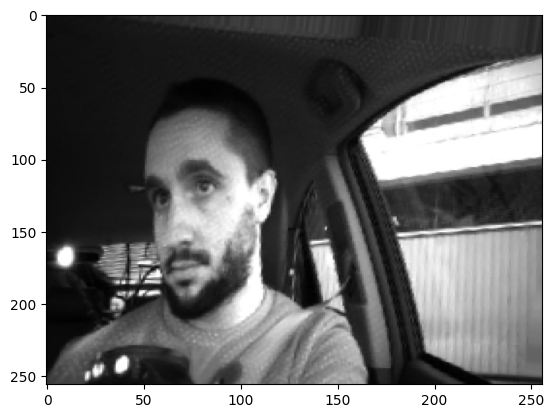

In [71]:
for data_batch,label_batch in train_generator:
    print(data_batch.shape) 
    print(label_batch.shape) 
    break

batch_x, batch_y = next(train_generator)
print(batch_x.shape, batch_x.min(), batch_x.max())
plt.imshow(np.squeeze(batch_x[0]), cmap='gray', aspect='auto')
plt.show()

In [72]:
#cpu handle random dropout cuz issue with CUDA
import tensorflow as tf
from keras.layers import Dropout

class CPUDropout(Dropout):
    def call(self, inputs, training=None):
        with tf.device('/CPU:0'):
            return super().call(inputs, training=training)


In [73]:
#CBAMN layers

@keras.saving.register_keras_serializable(package="ddd")
class ChannelAttention(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        c = int(input_shape[-1])
        hidden = max(c // self.ratio, 8)
        self.fc1 = layers.Dense(hidden, activation='relu', kernel_initializer='he_normal')
        self.fc2 = layers.Dense(c, activation='sigmoid', kernel_initializer='he_normal')
        self.fc1m = layers.Dense(hidden, activation='relu', kernel_initializer='he_normal')
        self.fc2m = layers.Dense(c, activation='sigmoid', kernel_initializer='he_normal')

    def call(self, x):
        avg = tf.reduce_sum(x, axis=[1,2]) / (tf.cast(tf.shape(x)[1]*tf.shape(x)[2], x.dtype))
        mx  = tf.reduce_max(x, axis=[1,2])
        ca = self.fc2(self.fc1(avg))
        cm = self.fc2m(self.fc1m(mx))
        w = tf.nn.sigmoid(ca + cm)
        w = tf.reshape(w, (-1,1,1,tf.shape(w)[-1]))
        return x * w

    def get_config(self):
        return {"ratio": self.ratio, **super().get_config()}

@keras.saving.register_keras_serializable(package="ddd")
class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.conv = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')

    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx  = tf.reduce_max(x, axis=-1, keepdims=True)
        s = tf.concat([avg, mx], axis=-1)     # HxWx2
        s = self.conv(s)                      # HxWx1
        return x * s


In [74]:
WD = 1e-5 

def conv_bn_act(x, filters, k=3, s=1, act='swish', wd=WD):
    x = layers.Conv2D(filters, k, strides=s, padding='same', use_bias=False,
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(wd))(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation(act)(x)

def se_block(x, reduction=8):
    c = x.shape[-1]
    s = layers.GlobalAveragePooling2D()(x)
    s = layers.Dense(max(c // reduction, 8), activation='relu', kernel_initializer='he_normal')(s)
    s = layers.Dense(c, activation='sigmoid', kernel_initializer='he_normal')(s)
    s = layers.Reshape((1,1,c))(s)
    return layers.Multiply()([x, s])

def residual_block(x, filters, stride=1, use_se=True, drop=0.0):
    shortcut = x
    y = conv_bn_act(x, filters, k=3, s=stride)
    y = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False,
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(WD))(y)
    y = layers.BatchNormalization()(y)
    if use_se:
        y = se_block(y)
    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False,
                                 kernel_initializer='he_normal',
                                 kernel_regularizer=regularizers.l2(WD))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    y = layers.Add()([shortcut, y])
    y = layers.Activation('swish')(y)
    if drop > 0.0:
        y = layers.SpatialDropout2D(drop)(y)
    return y

@keras.saving.register_keras_serializable(package="ddd")
class CBAM(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ca = ChannelAttention(ratio=ratio)
        self.sa = SpatialAttention()

    def call(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 1), n_classes=3):
    inputs = layers.Input(shape=input_shape)
    x = conv_bn_act(inputs, 32, k=5, s=2)  # 1/2
    x = layers.MaxPooling2D(2)(x)          # 1/4

    x = residual_block(x, 32, 1, drop=0.05)
    x = residual_block(x, 32, 1, drop=0.05)

    x = residual_block(x, 64, 2, drop=0.05)   # 1/8
    x = residual_block(x, 64, 1, drop=0.05)

    x = residual_block(x, 128, 2, drop=0.10)  # 1/16
    x = CBAM()(x)
    x = residual_block(x, 128, 1, drop=0.10)

    x = residual_block(x, 192, 2, drop=0.15)  # 1/32
    x = CBAM()(x)
    x = residual_block(x, 192, 1, drop=0.15)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='swish',
                     kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(WD))(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

model = build_model()
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 128, 128,  │        800 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_68       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ activation_68[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 64, 64,    │      9,216 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_69       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 64, 64,    │      9,216 │ activation_69[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 8)         │        264 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_129 (Dense)   │ (None, 32)        │        288 │ dense_128[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_32          │ (None, 1, 1, 32)  │          0 │ dense_129[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_32         │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Multiply)          │ 32)               │            │ reshape_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_32 (Add)        │ (None, 64, 64,    │          0 │ max_pooling2d_4[… │
│                     │ 32)               │            │ multiply_32[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_70       │ (None, 64, 64,    │          0 │ add_32[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,050,793 (7.82 MB)

 Trainable params: 2,046,633 (7.81 MB)

 Non-trainable params: 4,160 (16.25 KB)

In [75]:
def categorical_focal_loss(alpha, gamma=2.0):
    alpha = tf.constant(alpha, dtype=tf.float32)
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(weight * ce, axis=-1)
    return loss

# Heavier weight for the hard class (your c1)
alpha = [0.9, 1.6, 1.0]

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)


In [ ]:
#autocalculate class weight
labels = np.unique(train_generator.classes)
weights = compute_class_weight(
    class_weight="balanced",
    classes=labels,
    y=train_generator.classes
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    class_weight=class_weights,
)


# manual weights just in case
# class_weights = {
#     0: 1.0,  #Safe driving
#     1: 1.5,  #distracted
#     2: 1.8,  #tired
# }

Class weights: {0: np.float64(0.5511057173678533), 1: np.float64(1.3555555555555556), 2: np.float64(2.2333333333333334)}


/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
  1/128 ━━━━━━━━━━━━━━━━━━━━ 54:11 26s/step - accuracy: 0.3438 - loss: 1.1974

I0000 00:00:1762683093.042209  144703 subprocess_compilation.cc:347] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion_3', 144 bytes spill stores, 148 bytes spill loads



128/128 ━━━━━━━━━━━━━━━━━━━━ 59s 260ms/step - accuracy: 0.3958 - loss: 1.0693 - val_accuracy: 0.1493 - val_loss: 1.2733
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 20s 152ms/step - accuracy: 0.5062 - loss: 0.9286 - val_accuracy: 0.1508 - val_loss: 1.4783
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.5582 - loss: 0.8583 - val_accuracy: 0.2340 - val_loss: 1.4900
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.5970 - loss: 0.8177 - val_accuracy: 0.3025 - val_loss: 1.2549
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - accuracy: 0.6258 - loss: 0.7782 - val_accuracy: 0.4356 - val_loss: 0.9789
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.6370 - loss: 0.7633 - val_accuracy: 0.5296 - val_loss: 0.8805
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.6627 - loss: 0.7345 - val_accuracy: 0.6016 - val_loss: 0.8408
Epoch 8/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 18s 138ms/step - accuracy: 0.6801 - loss: 0.7146 - val

In [82]:
#fine tune
from tensorflow.keras.optimizers import Adam

alpha = [0.8, 1.2, 1.6]  # c0, c1, c2
model.compile(optimizer=tf.keras.optimizers.Adam(5e-6),
    loss=categorical_focal_loss(alpha=alpha, gamma=2.0),
    metrics=['accuracy'])


history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight= class_weights,
)


Epoch 1/10
  1/128 ━━━━━━━━━━━━━━━━━━━━ 45:45 22s/step - accuracy: 0.9062 - loss: 0.2021

I0000 00:00:1762684707.921312  144705 subprocess_compilation.cc:347] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion_3', 144 bytes spill stores, 148 bytes spill loads



128/128 ━━━━━━━━━━━━━━━━━━━━ 57s 277ms/step - accuracy: 0.9078 - loss: 0.1618 - val_accuracy: 0.7709 - val_loss: 0.3891
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - accuracy: 0.9097 - loss: 0.1511 - val_accuracy: 0.7680 - val_loss: 0.3920
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.9052 - loss: 0.1444 - val_accuracy: 0.7768 - val_loss: 0.3714
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 18s 137ms/step - accuracy: 0.9045 - loss: 0.1452 - val_accuracy: 0.7729 - val_loss: 0.3702
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 20s 154ms/step - accuracy: 0.9008 - loss: 0.1435 - val_accuracy: 0.7690 - val_loss: 0.3716
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.8971 - loss: 0.1446 - val_accuracy: 0.7768 - val_loss: 0.3542
Epoch 7/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 19s 148ms/step - accuracy: 0.8954 - loss: 0.1492 - val_accuracy: 0.7699 - val_loss: 0.3580
Epoch 8/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 18s 140ms/step - accuracy: 0.8964 - loss: 0.1422 - val

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step
              precision    recall  f1-score   support

          c0       0.80      0.85      0.82      1236
          c1       0.88      0.42      0.57       502
          c2       0.62      1.00      0.77       305

    accuracy                           0.77      2043
   macro avg       0.77      0.76      0.72      2043
weighted avg       0.79      0.77      0.75      2043



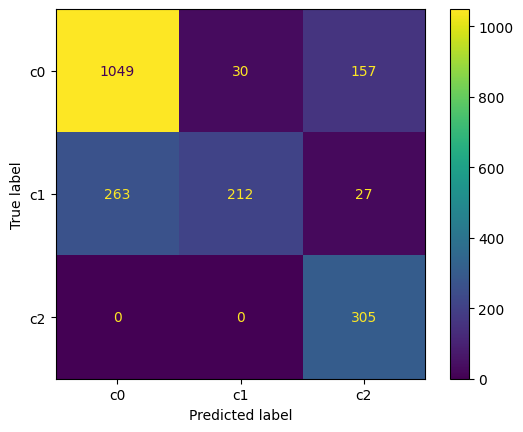

In [83]:
#training summary

# Metrics on the validation split
val_generator.reset()
val_preds = model.predict(val_generator)
y_pred = np.argmax(val_preds, axis=1)
y_true = val_generator.classes
print(classification_report(y_true, y_pred, target_names=list(train_generator.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=list(train_generator.class_indices.keys())).plot()
plt.show()

# Save: to avoid custom loss deserialization errors later, load with compile=False
model.save("distracted_driver_detection.keras")


In [79]:
tr_loss = history.history['loss']
tr_accuracy = history.history['accuracy']

val_loss = history.history['val_loss']
val_accuracy = history.history['val_accuracy']

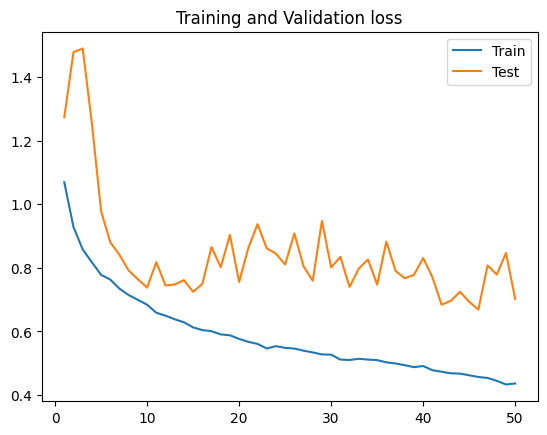

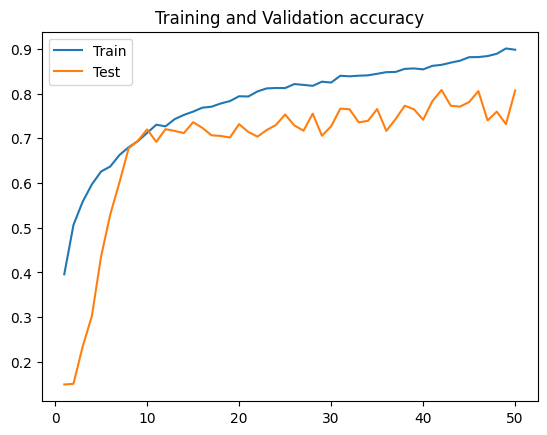

In [80]:
#graph training results
epchs = list(range(1,len(tr_loss)+1))
plt.plot(epchs,tr_loss,label='Train')
plt.plot(epchs,val_loss,label='Test')
plt.title("Training and Validation loss")
plt.legend()
plt.show()


plt.plot(epchs,tr_accuracy,label='Train')
plt.plot(epchs,val_accuracy,label='Test')
plt.title("Training and Validation accuracy")
plt.legend()
plt.show()

/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'cbam_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'cbam_9', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Saved predictions grid to testpics.png


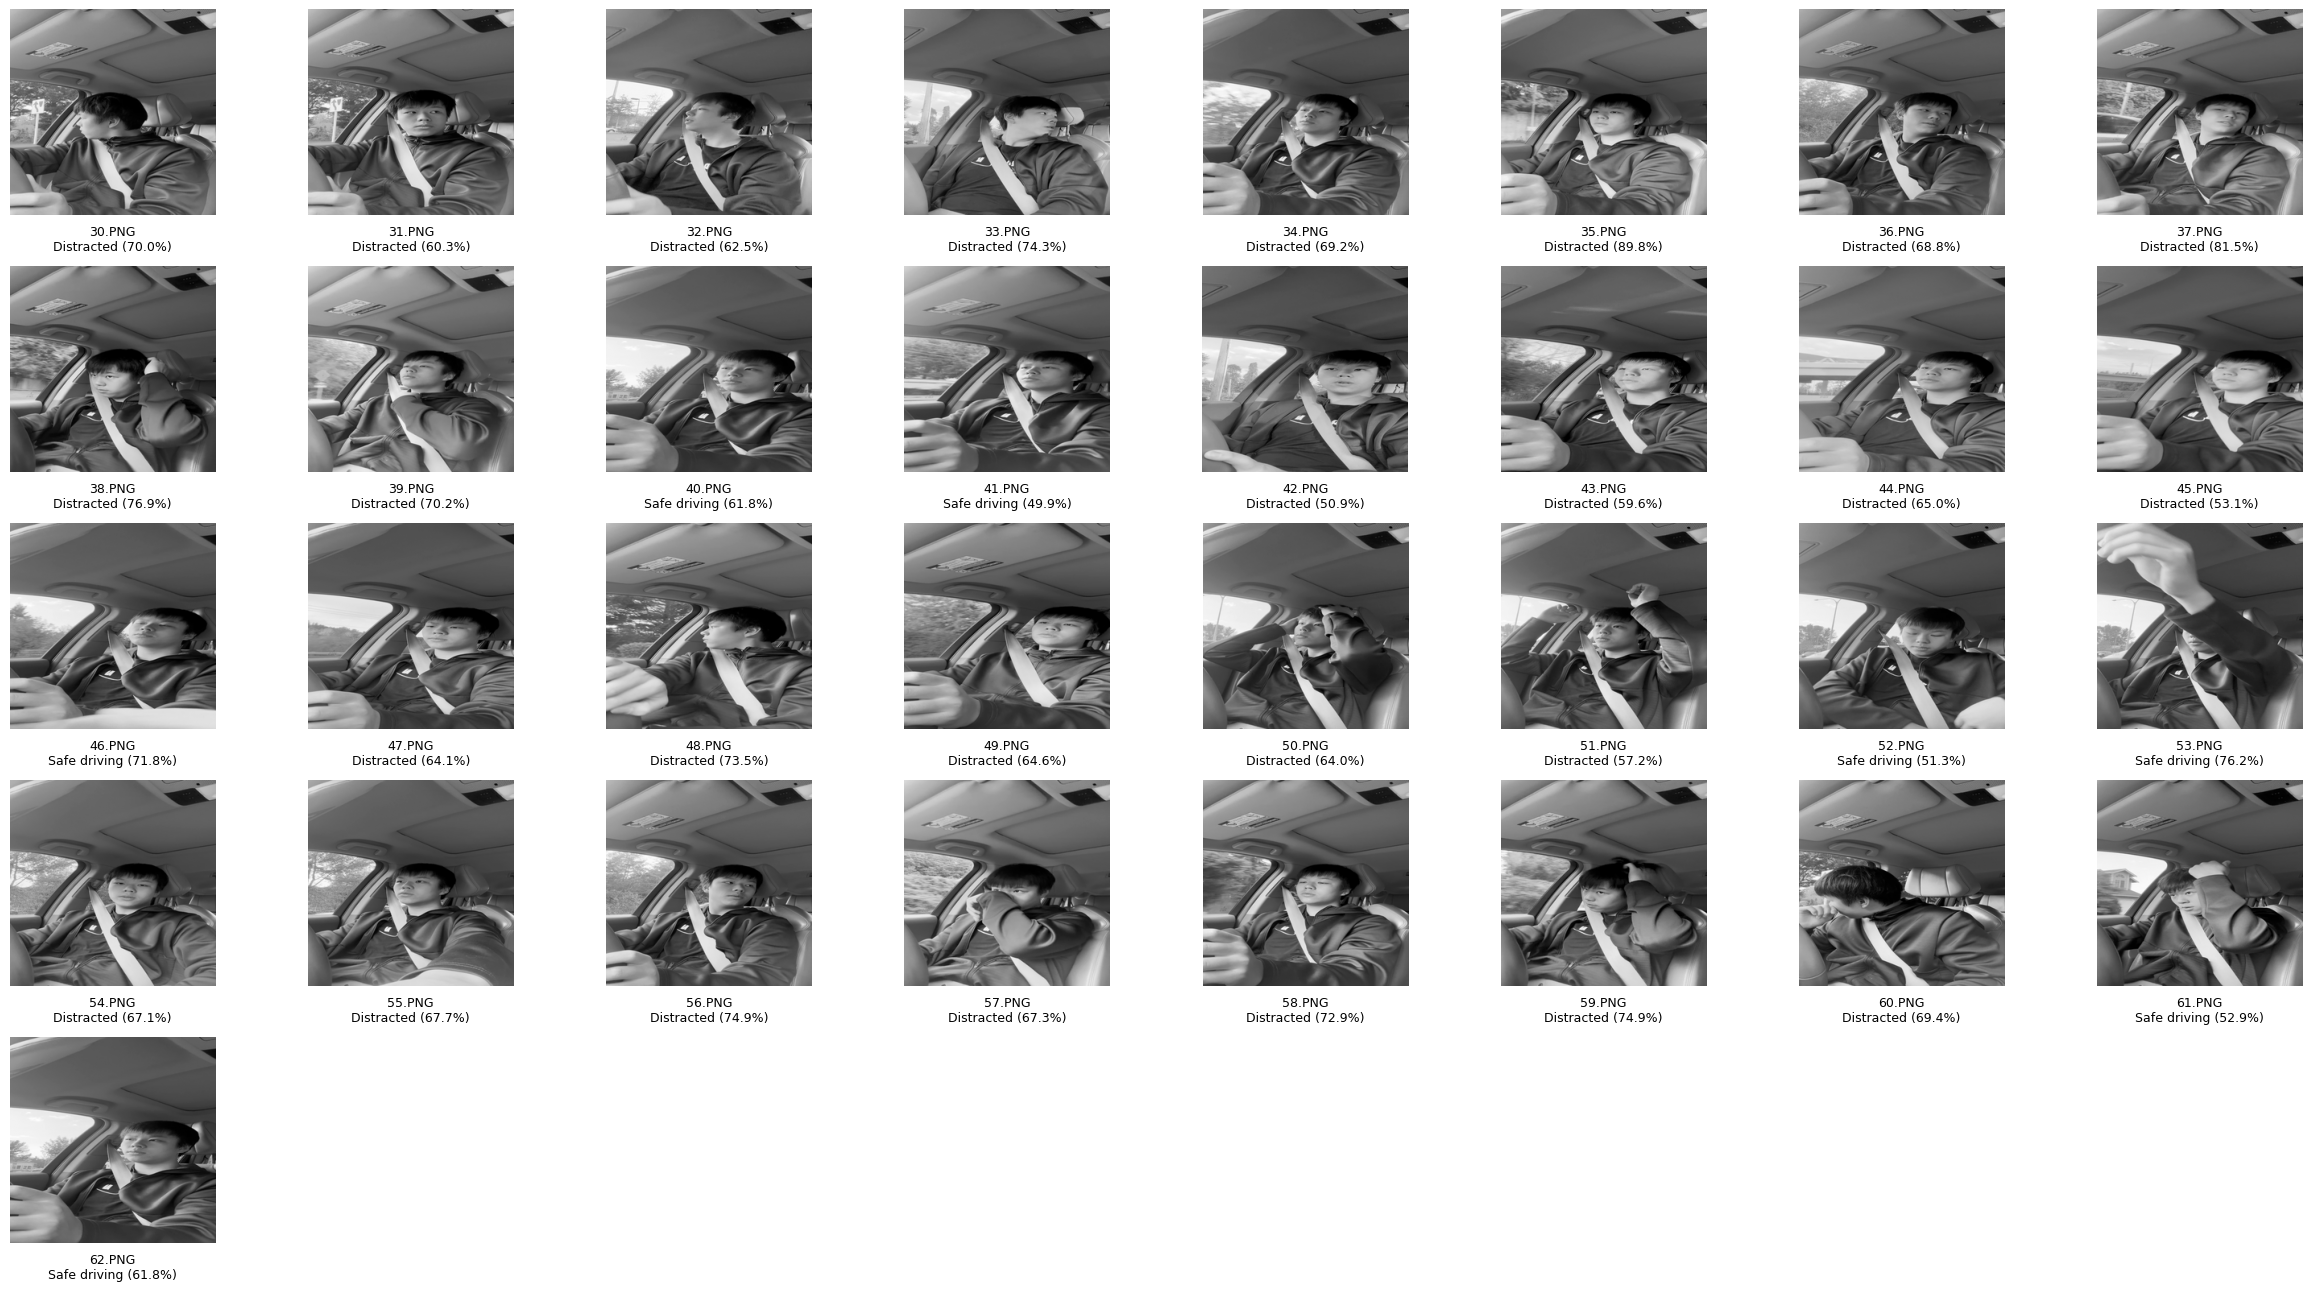

In [81]:
# test model with real data and show results
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dropout
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import os
import math
import keras
keras.config.enable_unsafe_deserialization()

def to_rgb(x):
    return tf.image.grayscale_to_rgb(x)

from tensorflow.keras.models import load_model
model = load_model("distracted_driver_detection.keras", compile=False) 

class_names = ["Safe driving", "Distracted", "Tired"]

folder = "/home/lurpd/DevelopmentWSL2/Datasets/MyData/"

image_paths = []
for i in range(30, 63):
    for ext in [".png", ".PNG", ".jpg", ".JPG", ".jpeg", ".JPEG"]:
        candidate = os.path.join(folder, f"{i}{ext}")
        if os.path.exists(candidate):
            image_paths.append(candidate)
            break  

cols = 8
rows = math.ceil(len(image_paths) / cols)
max_width_px = 2500
max_height_px = 1300
dpi = 100
fig_width = min(max_width_px / dpi, cols * 3)
fig_height = min(max_height_px / dpi, rows * 3)
plt.figure(figsize=(fig_width, fig_height), dpi=dpi)

for idx, img_path in enumerate(image_paths):
    img = Image.open(img_path).convert("L")
    img = img.resize((256, 256), Image.Resampling.LANCZOS)
    img_array = np.expand_dims(np.array(img).astype(np.float32) / 255.0, axis=(0, -1))

    predictions = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(predictions, axis=1)[0]
    predicted_label = class_names[predicted_class]
    confidence = np.max(predictions) * 100

    plt.subplot(rows, cols, idx + 1)
    plt.imshow(np.squeeze(img), cmap='gray', aspect='equal')
    plt.axis("off")
    plt.text(
        0.5, -0.05,
        f"{os.path.basename(img_path)}\n{predicted_label} ({confidence:.1f}%)",
        fontsize=9,
        ha="center", va="top",
        transform=plt.gca().transAxes
    )

plt.tight_layout()
plt.draw()

output_path = "testpics.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Saved predictions grid to {output_path}")

try:
    if os.path.exists("/mnt/c/Windows"):
        os.system(f"explorer.exe {output_path.replace('/', '\\\\')}")
    else:
        os.system(f"xdg-open {output_path}")
except Exception as e:
    print(f"Could not auto-open image: {e}")
